In [ ]:
#Spectral plume model, based on Zhou et al, 2019
#    https://doi.org/10.1175/JAS-D-18-0330.1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.io import loadmat
from scipy.io import savemat
import os
from metpy.calc import saturation_mixing_ratio
from metpy.units import units
from metpy.calc import moist_lapse
from metpy.calc import virtual_temperature
from metpy.calc import static_stability
from newcasenum import newcasenum
from newlab import newlab
from metpy.calc import dewpoint_from_relative_humidity, surface_based_cape_cin

In [2]:
#Colormap creator
def gradsmap():
    # Define the colormap matrix
    gradsmap2 = np.array([
        [10, 50, 120],
        [15, 75, 165],
        [30, 110, 200],
        [60, 160, 240],
        [80, 180, 250],
        [130, 210, 255],
        [160, 240, 255],
        [200, 250, 255],
        [230, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        [255, 250, 220],
        [255, 232, 120],
        [255, 192, 60],
        [255, 160, 0],
        [255, 96, 0],
        [255, 50, 0],
        [225, 20, 0],
        [192, 0, 0],
        [165, 0, 0]
    ]) / 255.0
    
    # Create a colormap from the array
    cmap = mcolors.ListedColormap(gradsmap2)
    
    return cmap
#Alternate colormap
def gradsmapf():
    # Define the colormap matrix
    gradsmap2 = np.array([
        [10, 50, 120],
        [15, 75, 165],
        [30, 110, 200],
        [60, 160, 240],
        [80, 180, 250],
        [130, 210, 255],
        [160, 240, 255],
        [200, 250, 255],
        [230, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        [255, 250, 220],
        [255, 232, 120],
        [255, 192, 60],
        [255, 160, 0],
        [255, 96, 0],
        [255, 50, 0],
        [225, 20, 0],
        [192, 0, 0],
        [165, 0, 0]
    ]) / 255.0
    # Create a colormap from the array
    cmap = mcolors.ListedColormap(np.flipud(gradsmap2))
    
    return cmap
#Oh look, it's another color map!
def gradsmap0b():
    # Define the colormap matrix
    gradsmap2 = np.array([
        [10, 50, 120],
        [15, 75, 165],
        [30, 110, 200],
        [60, 160, 240],
        [80, 180, 250],
        [130, 210, 255],
        [160, 240, 255],
        [200, 250, 255],
        [230, 255, 255],
        [255, 255, 255],
    ]) / 255.0
    # Create a colormap from the array
    cmap = mcolors.ListedColormap(gradsmap2)


    
    return cmap
#An excessive number of alternate colormaps
def gradsmap0():
    # Define the colormap matrix
    gradsmap2 = np.array([
        [255, 255, 255],
        [255, 250, 220],
        [255, 232, 120],
        [255, 192, 60],
        [255, 160, 0],
        [255, 96, 0],
        [255, 50, 0],
        [225, 20, 0],
        [192, 0, 0],
        [165, 0, 0]
    ]) / 255.0  # Normalize to [0, 1] range
    
    # Create a colormap from the array
    cmap = mcolors.ListedColormap(gradsmap2)
    
    return cmap
#You guessed it: it's a colormap!
def gradsmap0f():
    # Define the colormap matrix
    gradsmap2 = np.array([
        [255, 255, 255],
        [255, 250, 220],
        [255, 232, 120],
        [255, 192, 60],
        [255, 160, 0],
        [255, 96, 0],
        [255, 50, 0],
        [225, 20, 0],
        [192, 0, 0],
        [165, 0, 0]
    ]) / 255.0  # Normalize to [0, 1] range
    
    # Create a colormap from the array
    cmap = mcolors.ListedColormap(np.flipud(gradsmap2))

    
    return cmap

In [3]:
#Get entrainment profile
def get_entz(z_lev,params):
    z_tops = np.tile(params.z_top,(np.shape(z_lev)[1],1)).T
    z_bases = np.tile(params.z_base,(np.shape(z_lev)[1],1)).T
    dzte = np.subtract(z_tops,z_lev)
    dztzb = np.subtract(z_tops,z_bases)
    dzzb = np.subtract(z_lev,z_bases)
    #dzte = np.subtract(params.z_top,z_lev)
    #dztzb = np.subtract(params.z_top,params.z_base)
    entz = np.power(np.divide(params.eps*dzte,dztzb),params.k);
    entz[dzzb<=0] = 0
    entz[dzte<=0] = 0
    
    return entz
#Get z_top and z_base, as defined by mse and cloud base
def get_zbounds(z_lev,pb_ind,mse,params,do_ztp):
    params.z_base = z_lev[:,pb_ind]
    #hb = mse[:,pb_ind+1]
    hb = mse[:,pb_ind]
    if do_ztp:
        params.z_top = 12000#(hb-0.84*255)/params.g
        #print(np.max(params.z_top))
    else:
        mse=mse[:,0:pb_ind]
        zb = z_lev[:,0:pb_ind]
        hb = np.tile(hb,(np.shape(mse)[1],1)).T
        d=hb>=mse
        inds=np.argmax(d==1, axis=1)
        params.z_top = zb[np.arange(0,20),inds]
    
    return params
#Get RHS profile
def get_rhs(rhr,entr,qvr,params):
    rhsr = np.multiply((1-rhr),(params.Lv/params.Cp)*qvr)
    rhsz = np.multiply(entr,rhsr)
    
    return rhsz
#Get parameters
class get_params:
    def __init__(self, eps,eta):
        self.Lv = 2.25e6 #J/kg
        self.Rv = 461.5 #J/kgK
        self.Rd = 287 #J/kgK
        self.Cp = 1004 #J/kgK
        self.eta = .75
        self.g = 9.81
        self.k = 1 
        #self.eta = 0.75
        self.eta = eta
        self.eps = eps
#Get lambda profile     
def get_lam(z_lev,entl,params):
    z_tops = np.tile(params.z_top,(np.shape(z_lev)[1],1)).T
    z_bases = np.tile(params.z_base,(np.shape(z_lev)[1],1)).T
    dzte = np.subtract(z_tops,z_lev)
    dztzb = np.subtract(z_tops,z_bases)
    dzzb = np.subtract(z_lev,z_bases)
    laml = 1 + np.multiply(params.eta*entl,dzzb)
    lamr = np.divide(-1*params.k,dzte)
    lamz = np.divide(lamr,laml)
    lamz[z_lev>z_tops] = np.nan
    lamz[z_lev<z_bases] = np.nan
    
    return lamz
def get_hprof(z_lev,lamh,rhsh,mse,pb_ind,params):
    h = np.zeros(np.shape(z_lev))
    h[:,pb_ind:] = mse[:,pb_ind:]
    for z in range(pb_ind-2,-1,-1):
        dz = np.subtract(z_lev[:,z],z_lev[:,z+1])
        #Predict the value h(k) using forward Euler
        hlam0 = np.multiply(lamh[:,z+1],h[:,z+1])
        heulr0 = np.add(hlam0,rhsh[:,z+1])
        h_eul = h[:,z+1] + np.multiply(dz,heulr0) 
        #Now use the trapezoidal rule to integrate 
        #from k-1 to k using h_eul in place of h(k)
        hlam = np.multiply(lamh[:,z],h_eul)
        heulr = np.add(hlam,rhsh[:,z])
        h[:,z] = h[:,z+1] + 0.5*np.multiply(dz,np.add(heulr0, heulr)) 
    z_tops = np.tile(params.z_top,(np.shape(z_lev)[1],1)).T
    z_bases = np.tile(params.z_base,(np.shape(z_lev)[1],1)).T
    dzte = np.subtract(z_tops,z_lev)
    dztzb = np.subtract(z_tops,z_bases)
    dzzb = np.subtract(z_lev,z_bases)
    h[dzzb<=0] = 0
    h[dzte<=0] = 0
    #Because I went from base up, multiply by -1 (reverse integral)
    return -1*h
#Get dT Profile
def get_dt(h,temp,qvs,params):
    denomb = np.divide(params.Lv,np.multiply(params.Rv,np.power(temp,2)))
    denom = 1 + np.multiply(denomb,(params.Lv/params.Cp)*qvs)
    dt = np.divide(h,denom)
    t = np.add(temp,dt)
    
    return dt, t
def spec_plume(z_levs,pfull,temp,msep,rhp,eps_val,pbi,do_filter,eta_val,doztp):
    #pbi = 25 #cloud base index
    #Set parameters
    all_params = get_params(eps_val,eta_val)
    all_params = get_zbounds(z_levs,pbi,msep,all_params,doztp)
    #Get moist adiabat from surface
    #t_moist=moist_lapse(pfull*units.hPa, (temp[:,-1]-273.15)*units.degC, reference_pressure=pfull[-1]*units.hPa)*units.K
    #t_moist = t_moist.magnitude
    #Get moist adiabat from cloud base
    #tm = moist_lapse(pfull[0:pbi+1]*units.hPa, (temp[:,pbi+1]-273.15)*units.degC, reference_pressure=pfull[pbi+1]*units.hPa)*units.K
    #tm = tm.magnitude
    #t_moist = np.full(np.shape(temp),np.nan)
    #t_moist[:,0:pbi+1] = tm
    t_moist = get_moist_lapse(pfull,temp,pbi)

    #Get saturation mixing ratio
    qvsp = saturation_mixing_ratio(np.tile(pfull,[1,20]).T* units.hPa, \
                                  (t_moist-273.1) * units.degC).to('kg/kg')
    #Get entrainment profile
    entp = get_entz(z_levs,all_params)
    #Get RHS profile
    rhsp = get_rhs(rhp,entp,qvsp,all_params)
    #Get Lambda profile
    lamp = get_lam(z_levs,entp,all_params)
    #Get dh profile
    hp = get_hprof(z_levs,lamp,rhsp,msep,pbi,all_params)
    #Get temperature profile
    dtp, t_prof = get_dt(hp,t_moist,qvsp,all_params)
    if do_filter:
        t_prof = zfilter(t_prof,z_levs,all_params)
    tv_prof, qv_prof = get_tv(t_prof,msep,hp,z_levs,all_params)


    return t_prof, tv_prof,entp, rhsp, lamp, hp, dtp

def zfilter(fvar,z_lev,params):
    z_tops = np.tile(params.z_top,(np.shape(z_lev)[1],1)).T
    z_bases = np.tile(params.z_base,(np.shape(z_lev)[1],1)).T
    dzte = np.subtract(z_tops,z_lev)
    dztzb = np.subtract(z_tops,z_bases)
    dzzb = np.subtract(z_lev,z_bases)
    fvar[dzzb<0] = np.nan
    fvar[dzte<=0] = np.nan
    
    return fvar
#Get q
def get_tv(t,mse,h,z_lev,params):
    newh = mse + h
    #qv = (h - cp*t - gz)/lv
    qv = (newh - params.Cp*t - params.g*z_lev)/params.Lv
    tv = virtual_temperature(t * units.K, qv)
    
    return tv.magnitude, qv
#Get Cape
def get_cape(tv_prof,tv_model):
    cape = np.divide(np.subtract(tv_prof,tv_model),tv_model)
    
    return cape
#Moist lapse rate
def get_moist_lapse(p,t,pbim):
    #Moist lapse rate up from cloud base
    t_moist = np.full(np.shape(t),np.nan)
    p =(p[0:pbim].ravel())*units.hPa
    t = (t[:,pbim] - 273.15)*units.degC
    t_moist[:,1:pbim+1] = (moist_lapse(p, t, reference_pressure=p[-1])*units.K).magnitude
    #t_moist[:,pbim+d] = t_moist[:,pbim+d-1]
    
    return t_moist

f299rd2
f299rx1
f299rx3d2
f299rx2
f299rx3
f302rd2
fixedn1
f302rx3d2b
fixedn1x2
f302rx3
f303rd2
f303r1
f303rx3d2
f303rx2
f303rx3
f305rd2
fixedn1p3
f305rx3d2
f305rx2
f305rx3


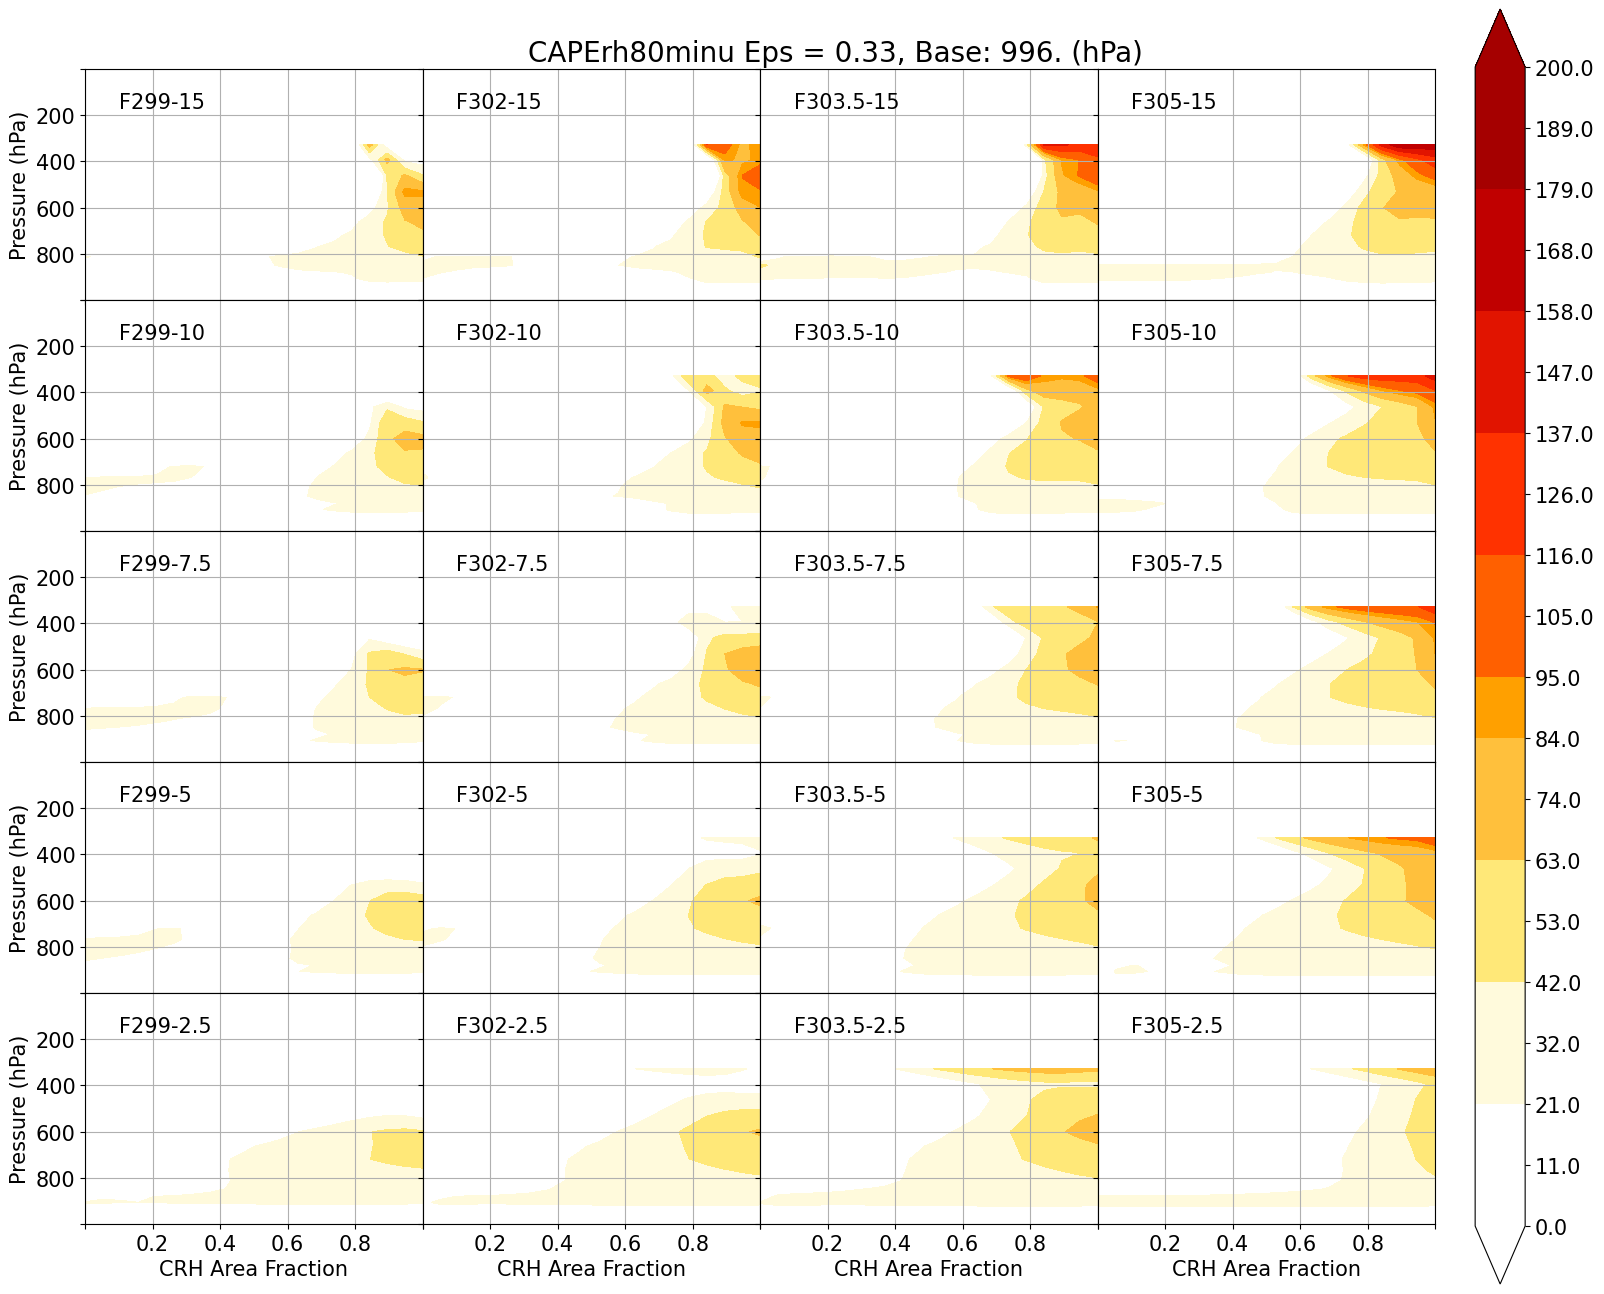

In [22]:
#Objectively not a great way to run a bunch of different variables
#This actually mostly just saves the variables to be plotted in a different jupyter notebook (Subplots)
#The plots are mostly just to check them before saving
#Change "plot_this" to variable
#plot_this = 'tdif'
#plot_this = 'tdifrhplume'
#plot_this = 'tdifrhmod'

#plot_this = 'tmoistdif'
#plot_this = 'cape3d'
#plot_this = 'mse-mseb'
#plot_this = 'rh'
#plot_this = 'tvdifrh80'
#plot_this = 'tv_plume-tv_model'
#plot_this = 'CAPErh80u'
plot_this = 'CAPErh80minu'
#plot_this = 'CAPErh40u'
#plot_this = 'CAPErh40maxu'
#plot_this = 'CAPErh20maxu'
#plot_this = 'CAPE'
p40 = 19
saverh40=1
#plot_this='CAPE'
#plot_this = 'CIN'
#plot_this = 'tdtconv'
plotrh=0
#rhval=.4
lab=''
dofztop = 1
#Set entrainment parameter here
eps1 = .33/1000
#eps1=.2/1000
#eps1 = 0
#eps1=.45/1000
#Some other parameters
eta1 = .75
pbi1 = 31
dofilt=1
crh_window = 0
g=9.81
Rd = 287
Rv = 461.5
Lv = 2501000
Cp = 1003.5
rh = .8
dosave = 1
if crh_window == 0:
    aa = 0
    bb = 20
elif crh_window == 1:
    aa = 0
    bb = 6
elif crh_window == 2:
    aa = 7
    bb = 14
elif crh_window == 3:
    aa = 15
    bb = 20
    
a=0
b=0
casenumsc = ['f299rd2','f299rx1','f299rx3d2', 'f299rx2', 'f299rx3', 'f302rd2','fixedn1', 'f302rx3d2b',
             'fixedn1x2', 'f302rx3', 'f303rd2', 'f303r1', 'f303rx3d2','f303rx2','f303rx3',
             'f305rd2', 'fixedn1p3', 'f305rx3d2', 'f305rx2','f305rx3']
indssts = [1,1,1, 1, 1, 2,2, 2, 2, 2, 3,3,3, 3, 3, 4,4, 4, 4, 4]
indranges = [1,2,3, 4, 5, 1,2, 3, 4, 5, 1, 2, 3,4,5, 1, 2, 3, 4,5]
#flippling so that high sst grad is on top
indranges = np.flip(indranges)
path = '/home/disk/eos8/bdygert/code/compredo/'
cn = len(casenumsc)
ib = 0
#ib = 400
# Create a figure
fig, axs = plt.subplots(5, 4, figsize=(20, 15))  # Adjust figure size as needed
axs = axs.flatten()
plt.subplots_adjust(hspace=0, wspace=0)
#Loop through cases
for j in range(0,cn):
    casenum = casenumsc[j]
    print(casenum)
    #Get temp
    flnm = path + casenum+'temp2dcrh.mat'
    data = loadmat(flnm)
    temp0 = data['stf']
    temp0=np.mean(temp0[0:20,:,:],2)
    pfull0=data['pfull']
    alin=data['alin']
    #Get z
    flnm = path + casenum+'z_full2dcrh.mat'
    data = loadmat(flnm)
    zfull0=data['stf']
    zfull0=np.mean(zfull0[0:20,:,:],2)
    #Get RH
    flnm = path + casenum+'rh2dcrh.mat'
    data = loadmat(flnm)
    rh0 = data['stf']
    rh0=np.mean(rh0[0:20,:,:],2)/100
    #Get mse
    flnm = path + casenum+'mse2dcrh.mat'
    data = loadmat(flnm)
    mse0 = data['stf']
    mse0=np.mean(mse0[0:20,:,:],2)
    #Get moist lapse profile
    tm = get_moist_lapse(pfull0,temp0,pbi1)
    rh40 = .8*np.ones(np.shape(rh0))
    rh40[:,0:p40] = 0.4
    if plot_this == 'CAPErh40maxu':
        rh40a = rh40
        rhp40 = np.array(rh0)
        rhp40[rh0>.4] = .4
        rh40 = np.array(rh0)
        rh40[:,0:p40] = rhp40[:,0:p40]
    elif plot_this == 'CAPErh20maxu':
        rh40a = rh40
        rhp40 = np.array(rh0)
        rhp40[rh0>.2] = .2
        rh40 = np.array(rh0)
        rh40[:,0:p40] = rhp40[:,0:p40]
        if np.sum(np.subtract(rh40,rh0))>0:
            print('oh no')
    elif plot_this == 'CAPErh80minu':
        rh40a = rh40
        rhp40 = np.array(rh0)
        rhp40[rh0<.8] = .8
        rh40 = np.array(rh0)
        rh40[:,:] = rhp40[:,:]


    qvs_tm = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (tm-273.1) * units.degC).to('kg/kg')
    tprof, tv,ent, rhs, lam, hprof, dT = spec_plume(zfull0,pfull0,temp0,mse0,rh0,eps1,pbi1,dofilt,eta1,dofztop)
    tprofrh80,tvrh80,ent80,rhs80,lam80,hprof80,dT80 = spec_plume(zfull0,pfull0,temp0,mse0,.8*np.ones(np.shape(rh0)),eps1,pbi1,dofilt,eta1,dofztop)
    tprofrh40,tvrh40,ent40,rhs40,lam40,hprof40,dT40 = spec_plume(zfull0,pfull0,temp0,mse0,rh40,eps1,pbi1,dofilt,eta1,dofztop)
    #tprof = zfilter(tprof,zfull0,paramz)
    #tprofrh80 = zfilter(tprofrh80,zfull0,paramz)

    #Plotting stuff
    ax = axs[indssts[j] - 1 + (indranges[j] - 1) * 4]  # Adjust index for subplots
    if indssts[j]!=1:
        #ax.set_yticks([])
        ax.set_yticks([0,200,400,600,800,1000])
        ax.set_yticklabels([])
    else:
        ax.set_ylabel('Pressure (hPa)',fontsize=15)
        ax.set_yticks([0,200,400,600,800,1000])
        ax.set_yticklabels(['',200,400,600,800,''],fontsize=15)
    if indranges[j]!=5:
        #ax.set_xticks([])
        ax.set_xticks([0,.2,.4,.6,.8,1])
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('CRH Area Fraction',fontsize=15)
        ax.set_xticks([0,.2,.4,.6,.8,1])
        ax.set_xticklabels(['',.2,.4,.6,.8,''],fontsize=15)

    ax.set_ylim(ib, 1000)
    ax.invert_yaxis()
    ax.grid(True)
    connum=20
    if plot_this == 'tdif':
        a= 0
        b= 15
        convals = tprof - temp0
        scmap = gradsmap()
        lab = 'T Plume - T GCM (K)'
        if crh_window == 3:
            a = -9
            b = 9
            #a = np.nanmin([a,np.nanmin(convals.ravel())])
            #b = np.nanmax([b,np.nanmax(convals.ravel())])
        if dofztop:
            a = -35
            b = 35
    elif plot_this == 'tdifrhmod':
        a= -15
        b= 15
        convals = tprofrh80 - temp0
        scmap = gradsmap()
        lab = 'T Plume (RH = 80%) - T GCM (K)'
        if crh_window == 3:
            a = -9
            b = 9
            #a = np.nanmin([a,np.nanmin(convals.ravel())])
            #b = np.nanmax([b,np.nanmax(convals.ravel())])
    elif plot_this == 'tdifrhplume':
        a= -15
        b= 15
        convals = tprofrh80 - tprof
        scmap = gradsmap()
        lab = 'T Plume (RH = 80%) - T Plume (RH from GCM) (K)'
        if crh_window == 3:
            a = -9
            b = 9
            #a = np.nanmin([a,np.nanmin(convals.ravel())])
            #b = np.nanmax([b,np.nanmax(convals.ravel())])
    elif plot_this == 'tmoistdif':
        #a= -15
        #b= 15
        convals = tm - temp0
        convals[:,0:10] = np.nan
        scmap = gradsmap()
        a = np.nanmin([a,np.nanmin(convals.ravel())])
        b = np.nanmax([b,np.nanmax(convals.ravel())])
    elif plot_this == 'mse-mseb':
        #a= -15
        #b= 15
        mse = Cp*tprof + g*zfull0 + .8*qvs_tm
        convals = (mse.T - mse0[:,pbi1].T).T
        #convals = tm - temp0
        convals[:,0:10] = np.nan
        scmap = gradsmap()
        a = np.nanmin([a,np.nanmin(convals.ravel())])
        b = np.nanmax([b,np.nanmax(convals.ravel())])
    elif plot_this == 'mse_err':
        #a= -15
        #b= 15
        mse = Cp*tprof + g*zfull0 + .8*qvs_tm
        #convals = (mse.T - mse0[:,pbi1].T).T
        convals = mse - mse0
        #convals = tm - temp0
        convals[:,0:10] = np.nan
        scmap = gradsmap()
        a = np.nanmin([a,np.nanmin(convals.ravel())])
        b = np.nanmax([b,np.nanmax(convals.ravel())])
    elif plot_this == 'tv':
        #qvs0 = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (temp0-273.1) * units.degC).to('kg/kg')
        #tv0 = virtual_temperature(temp0 * units.K, np.multiply(rh0,qvs0)).magnitude
        convals = tv#get_cape(tv,tv0)
        scmap = gradsmap0()
        a = 200
        b = 310
        scmap=gradsmap0()
    elif plot_this == 'tvdif':
        qvs0 = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (temp0-273.1) * units.degC).to('kg/kg')
        tv0 = virtual_temperature(temp0 * units.K, np.multiply(rh0,qvs0)).magnitude
        convals = tv-tv0#get_cape(tv,tv0)
        scmap = gradsmap()
        lab = 'Virtual Temperature Difference'
        a= -15
        b= 15
        #a = np.nanmin([a,np.nanmin(convals.ravel())])
        #b = np.nanmax([b,np.nanmax(convals.ravel())])
        scmap=gradsmap0()
    elif plot_this == 'tvdifrh80':
        convals = tvrh80-tv#get_cape(tv,tv0)
        scmap = gradsmap()
        lab = 'Virtual T (RH=80%) - Virtual T (RH from GCM)'
        a= -15
        b= 15
        #a = np.nanmin([a,np.nanmin(convals.ravel())])
        #b = np.nanmax([b,np.nanmax(convals.ravel())])
        scmap=gradsmap0()
    elif plot_this == 'tvdifplume':
        convals = tv-tprof#get_cape(tv,tv0)
        scmap = gradsmap0()
        a= 0
        b= 6
        #a = np.nanmin([a,np.nanmin(convals.ravel())])
        #b = np.nanmax([b,np.nanmax(convals.ravel())])
        scmap=gradsmap0()
    elif plot_this == 'tv_plume-tv_model':
        qvs0 = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (temp0-273.1) * units.degC).to('kg/kg')
        tv0 = virtual_temperature(temp0 * units.K, np.multiply(rh0,qvs0)).magnitude
        convals = tv-tv0#get_cape(tv,tv0)
        #a= -30
        #b= 30
        a = 0
        b = 10
        scmap = gradsmap()
    elif plot_this == 'CAPE' or plot_this == 'CIN':
        g=9.81
        qvs0 = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (temp0-273.1) * units.degC).to('kg/kg')
        tv0 = virtual_temperature(temp0 * units.K, np.multiply(rh0,qvs0)).magnitude
        dz = np.gradient(zfull0,axis=1)
        convals = -1*g*np.multiply(dz,np.divide(tv-tv0,tv0)) #CAPE = g * int_z0^zf[(tv,p-tv,e)/tv,e]dz
        #a= -30
        #b= 30
        a = -150
        b = 0
        if plot_this == 'CAPE':
            #convals[convals<0] = np.nan
            a= 0
            b= 200
            scmap = gradsmap()
        elif plot_this == 'CIN':
            #convals[convals>0] = np.nan
            scmap = gradsmap0f()
        csvnm = path + casenum + plot_this + str(round(eps1*10000)) + '2dcrh.mat'
        savemat(csvnm,{'stf':convals,'alin':alin,'pfull':pfull0})
        #if eps1 == .45/1000:
        #    b=50
    elif plot_this == 'CAPErh80u' or plot_this == 'CINrh80u':
        g=9.81
        qvs0 = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (temp0-273.1) * units.degC).to('kg/kg')
        tv0 = virtual_temperature(temp0 * units.K, np.multiply(.8,qvs0)).magnitude
        #tv0 = virtual_temperature(temp0 * units.K, np.multiply(.8,qvs0)).magnitude
        dz = np.gradient(zfull0,axis=1)
        convals = -1*g*np.multiply(dz,np.divide(tvrh80-tv0,tv0)) #CAPE = g * int_z0^zf[(tv,p-tv,e)/tv,e]dz
        a = -150
        b = 0
        if plot_this == 'CAPErh80u':
            #convals[convals<0] = np.nan
            a= 0
            b= 200
            scmap = gradsmap()
        elif plot_this == 'CINrh80u':
            #convals[convals>0] = np.nan
            scmap = gradsmap0f()

        #a= -30
        #b= 30
        #if eps1 == .45/1000:
        #    b=50
        csvnm = path + casenum + plot_this + str(round(eps1*10000)) + '2dcrh.mat'
        savemat(csvnm,{'stf':convals,'alin':alin,'pfull':pfull0})
        if saverh40:
            csvnm = path + casenum + plot_this[4:] + '2dcrh.mat'
            savemat(csvnm,{'stf':.8*np.ones(np.shape(convals)),'alin':alin,'pfull':pfull0})
    elif plot_this == 'CAPErh40u' or plot_this == 'CINrh40u':
        g=9.81
        qvs0 = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (temp0-273.1) * units.degC).to('kg/kg')
        tv0 = virtual_temperature(temp0 * units.K, np.multiply(rh40,qvs0)).magnitude
        #tv0 = virtual_temperature(temp0 * units.K, np.multiply(.8,qvs0)).magnitude
        dz = np.gradient(zfull0,axis=1)
        convals = -1*g*np.multiply(dz,np.divide(tvrh40-tv0,tv0)) #CAPE = g * int_z0^zf[(tv,p-tv,e)/tv,e]dz
        #a = -150
        #b = 0
        if plot_this == 'CAPErh40u':
            #convals[convals<0] = np.nan
            a= 0
            b= 200
            scmap = gradsmap()
        elif plot_this == 'CINrh40u':
            #convals[convals>0] = np.nan
            scmap = gradsmap0f()
    elif plot_this == 'CAPErh40maxu' or plot_this == 'CINrh40maxu':
        g=9.81
        qvs0 = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (temp0-273.1) * units.degC).to('kg/kg')
        tv0 = virtual_temperature(temp0 * units.K, np.multiply(rh40,qvs0)).magnitude
        #tv0 = virtual_temperature(temp0 * units.K, np.multiply(.8,qvs0)).magnitude
        dz = np.gradient(zfull0,axis=1)
        convals = -1*g*np.multiply(dz,np.divide(tvrh40-tv0,tv0)) #CAPE = g * int_z0^zf[(tv,p-tv,e)/tv,e]dz
        #a = -150
        #b = 0
        if plot_this == 'CAPErh40maxu':
            #convals[convals<0] = np.nan
            a= 0
            b= 200
            scmap = gradsmap()
        elif plot_this == 'CINrh40maxu':
            #convals[convals>0] = np.nan
            scmap = gradsmap0f()

        #a= -30
        #b= 30
        #if eps1 == .45/1000:
        #    b=50
        csvnm = path + casenum + plot_this + str(p40) + str(round(eps1*10000)) + '2dcrh.mat'
        savemat(csvnm,{'stf':convals,'alin':alin,'pfull':pfull0})
        if saverh40:
            csvnm = path + casenum + plot_this[4:] + str(p40) + '2dcrh.mat'
            savemat(csvnm,{'stf':rh40,'alin':alin,'pfull':pfull0})
    elif plot_this == 'CAPErh80minu':
        g=9.81
        qvs0 = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (temp0-273.1) * units.degC).to('kg/kg')
        tv0 = virtual_temperature(temp0 * units.K, np.multiply(rh40,qvs0)).magnitude
        dz = np.gradient(zfull0,axis=1)
        convals = -1*g*np.multiply(dz,np.divide(tvrh40-tv0,tv0)) #CAPE = g * int_z0^zf[(tv,p-tv,e)/tv,e]dz
        if plot_this == 'CAPErh80minu':
            a= 0
            b= 200
            scmap = gradsmap()
        csvnm = path + casenum + plot_this + str(round(eps1*10000)) + '2dcrh.mat'
        savemat(csvnm,{'stf':convals,'alin':alin,'pfull':pfull0})
        if saverh40:
            csvnm = path + casenum + plot_this[4:] + '2dcrh.mat'
            savemat(csvnm,{'stf':rh40,'alin':alin,'pfull':pfull0})
    elif plot_this == 'CAPErh20maxu' or plot_this == 'CINrh20maxu':
        g=9.81
        qvs0 = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (temp0-273.1) * units.degC).to('kg/kg')
        tv0 = virtual_temperature(temp0 * units.K, np.multiply(rh40,qvs0)).magnitude
        dz = np.gradient(zfull0,axis=1)
        convals = -1*g*np.multiply(dz,np.divide(tvrh40-tv0,tv0)) #CAPE = g * int_z0^zf[(tv,p-tv,e)/tv,e]dz
        if plot_this == 'CAPErh20maxu':
            a= 0
            b= 200
            scmap = gradsmap()
        elif plot_this == 'CINrh20maxu':
            scmap = gradsmap0f()
        csvnm = path + casenum + plot_this + str(p40) + str(round(eps1*10000)) + '2dcrh.mat'
        savemat(csvnm,{'stf':convals,'alin':alin,'pfull':pfull0})
        if saverh40:
            csvnm = path + casenum + plot_this[4:] + str(p40) + '2dcrh.mat'
            savemat(csvnm,{'stf':rh40,'alin':alin,'pfull':pfull0})
    elif plot_this == 'tvdifmodel':
        qvs0 = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (temp0-273.1) * units.degC).to('kg/kg')
        tv0 = virtual_temperature(temp0 * units.K, np.multiply(rh0,qvs0)).magnitude
        convals = tv0-temp0#get_cape(tv,tv0)
        scmap = gradsmap0()
        #a = 200
        #b = 310
        a= -15
        b= 15
        #a = np.nanmin([a,np.nanmin(convals.ravel())])
        #b = np.nanmax([b,np.nanmax(convals.ravel())])
        scmap=gradsmap0()
    elif plot_this == 'temp':
        #qvs0 = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (temp0-273.1) * units.degC).to('kg/kg')
        #tv0 = virtual_temperature(temp0 * units.K, np.multiply(rh0,qvs0)).magnitude
        convals = temp0#get_cape(tv,tv0)
        scmap = gradsmap0()
        a = 200
        b = 310
        scmap=gradsmap0()
    elif plot_this == 'cape3d':
        qvs0 = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (temp0-273.1) * units.degC).to('kg/kg')
        tv0 = virtual_temperature(temp0 * units.K, np.multiply(rh0,qvs0)).magnitude
        convals = get_cape(tv,tv0)

        scmap = gradsmap0()
        a = np.nanmin([a,np.nanmin(convals.ravel())])
        b = np.nanmax([b,np.nanmax(convals.ravel())])
    if ~crh_window:
        if aa>1:
            convals[0:aa-1,:] =np.nan
        if bb<20:
            convals[:bb+1] = np.nan
    if dofztop:
        convals[:,0:14] = np.nan
    if a * b < 0:
        scmap = gradsmap()
        c = max(abs(a), abs(b))
        a = -c
        b = c
        contl = np.concatenate([np.linspace(-c, 0, connum-1)[:-1], np.linspace(0, c, connum-1)])
    else:
        scmap = gradsmap0()
        contl = np.linspace(a, b, connum)
    if plot_this.startswith('CIN'):
        convals[np.isnan(convals)] = .00001
        scmap = gradsmap0f()
    cax = ax.contourf(np.ravel(alin), np.ravel(pfull0), convals.T, levels=contl, cmap=scmap, extend='both')
    ax.text(0.1, 0.9, newcasenum(casenum), fontsize=15,horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
    if a * b <0 or plot_this.startswith('CIN'):
        ax.contour(np.ravel(alin), np.ravel(pfull0), convals.T, 'k',levels=[0], extend='both')
    if plotrh:
        cs = ax.contour(np.ravel(alin), np.ravel(pfull0), rh0.T, 'k', levels=[rhval], extend='both')
        cs.clabel([rhval], inline=True, fontsize=10)
if lab=='':
    lab = newlab(plot_this)
pbi1p = pfull0[pbi1].ravel()
paramstr = ' Eps = ' + str(eps1*1000) + ', Base: ' + str(pbi1p[0])[0:4] +' (hPa)'
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.82, 0.07, 0.025, .85])
cbar = fig.colorbar(cax, cax=cbar_ax)
cbar.ax.set_yticks(contl)
cbar.ax.set_yticklabels(np.round(contl,0),fontsize=15)
fig.suptitle(lab + paramstr, y=.9,fontsize=20)
if dosave:
    fname = plot_this + 'fixedsstsubplots.pdf'
    if 'CAPErh40' in plot_this:
        fname = plot_this + str(p40) + 'fixedsstsubplots.pdf'
    plt.savefig(fname, dpi=400)
plt.show()

    
    
    
    

f299rd2
f299rx1
f299rx3d2
f299rx2
f299rx3
f302rd2
fixedn1
f302rx3d2b
fixedn1x2
f302rx3
f303rd2
f303r1
f303rx3d2
f303rx2
f303rx3
f305rd2
fixedn1p3
f305rx3d2
f305rx2
f305rx3


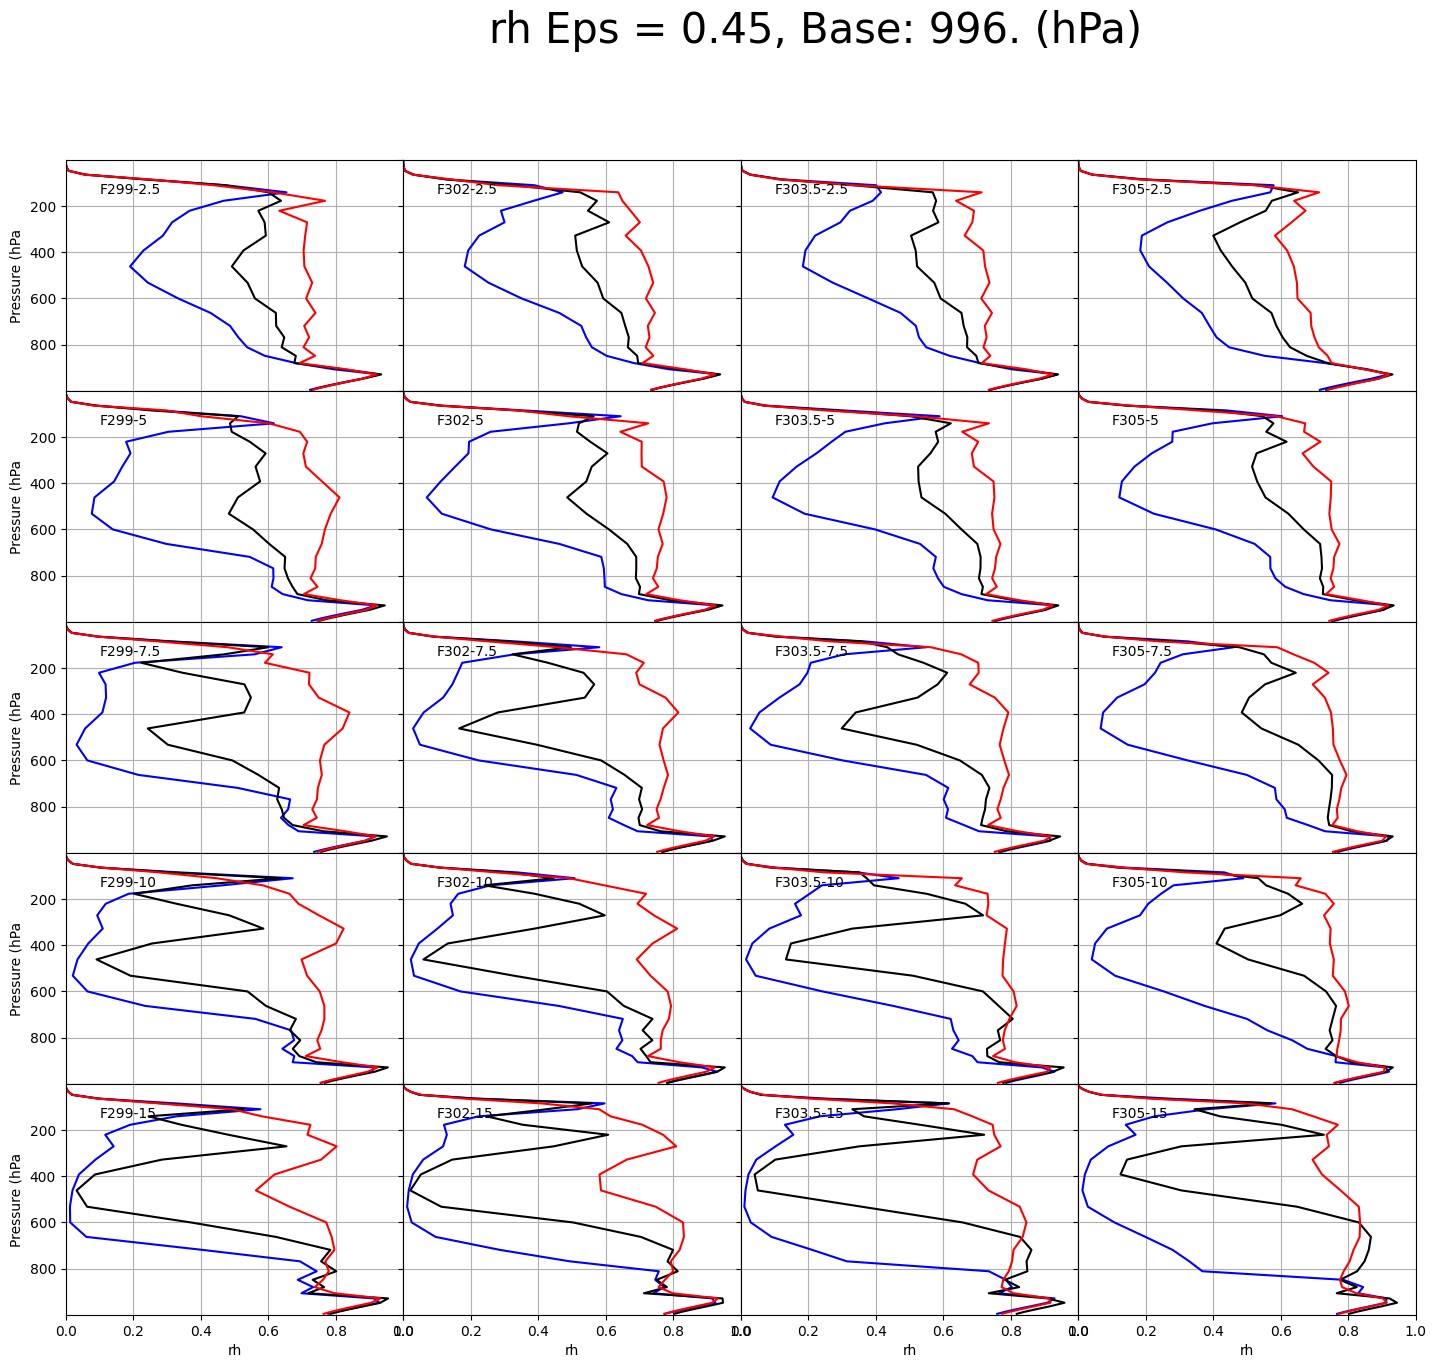

In [24]:
plot_this = 'rh'
dotemp = 0
ta = 12
tb = 15
#tc = 15
lab=''
dofztop = 1
#eps1 = .33/1000
eps1=.45/1000
eta1 = .75
pbi1 = 31
dofilt=1
crh_window = 0
g=9.81
Rd = 287
Rv = 461.5
Lv = 2501000
Cp = 1003.5
rh = .8
if crh_window == 0:
    aa = 0
    bb = 20
elif crh_window == 1:
    aa = 0
    bb = 6
elif crh_window == 2:
    aa = 7
    bb = 14
elif crh_window == 3:
    aa = 15
    bb = 20
    
a=0
b=0
casenumsc = ['f299rd2','f299rx1','f299rx3d2', 'f299rx2', 'f299rx3', 'f302rd2','fixedn1', 'f302rx3d2b',
             'fixedn1x2', 'f302rx3', 'f303rd2', 'f303r1', 'f303rx3d2','f303rx2','f303rx3',
             'f305rd2', 'fixedn1p3', 'f305rx3d2', 'f305rx2','f305rx3']
indssts = [1,1,1, 1, 1, 2,2, 2, 2, 2, 3,3,3, 3, 3, 4,4, 4, 4, 4]
indranges = [1,2,3, 4, 5, 1,2, 3, 4, 5, 1, 2, 3,4,5, 1, 2, 3, 4,5]
path = '/home/disk/eos8/bdygert/code/compredo/'
cn = len(casenumsc)
ib = 0
# Create a figure
fig, axs = plt.subplots(5, 4, figsize=(20, 15))  # Adjust figure size as needed
axs = axs.flatten()
plt.subplots_adjust(hspace=0, wspace=0)
#Loop through cases
for j in range(0,cn):
    casenum = casenumsc[j]
    print(casenum)
    #Get temp
    flnm = path + casenum+'temp2dcrh.mat'
    data = loadmat(flnm)
    temp0 = data['stf']
    temp0=np.mean(temp0[0:20,:,:],2)
    pfull0=data['pfull']
    alin=data['alin']
    #Get z
    flnm = path + casenum+'z_full2dcrh.mat'
    data = loadmat(flnm)
    zfull0=data['stf']
    zfull0=np.mean(zfull0[0:20,:,:],2)
    #Get RH
    flnm = path + casenum+'rh2dcrh.mat'
    data = loadmat(flnm)
    rh0 = data['stf']
    rh0=np.mean(rh0[0:20,:,:],2)/100
    #Get mse
    flnm = path + casenum+'mse2dcrh.mat'
    data = loadmat(flnm)
    mse0 = data['stf']
    mse0=np.mean(mse0[0:20,:,:],2)
    if plot_this == 'rh':
        thingsc = np.mean(rh0[0:ta,:],0)
        thingsi = np.mean(rh0[ta:tb,:],0)
        thingsh = np.mean(rh0[tb:,:],0)
    elif plot_this == 'CAPE':
        tm = get_moist_lapse(pfull0,temp0,pbi1)
        qvs_tm = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (tm-273.1) * units.degC).to('kg/kg')
        tprof, tv,ent, rhs, lam, hprof, dT = spec_plume(zfull0,pfull0,temp0,mse0,rh0,eps1,pbi1,dofilt,eta1,dofztop)
        tprofrh80,tvrh80,ent80,rhs80,lam80,hprof80,dT80 = spec_plume(zfull0,pfull0,temp0,mse0,.8*np.ones(np.shape(rh0)),eps1,pbi1,dofilt,eta1,dofztop)
        g=9.81
        qvs0 = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (temp0-273.1) * units.degC).to('kg/kg')
        tv0 = virtual_temperature(temp0 * units.K, np.multiply(rh0,qvs0)).magnitude
        dz = np.gradient(zfull0,axis=1)
        stf0 = -1*g*np.multiply(dz,np.divide(tv-tv0,tv0)) #CAPE = g * int_z0^zf[(tv,p-tv,e)/tv,e]dz
        thingsc = np.mean(stf0[0:ta,:],0)
        thingsi = np.mean(stf0[ta:tb,:],0)
        thingsh = np.mean(stf0[tb:,:],0)
        #a= -30
        #b= 30
        #a = -2000
        #b = 2000
    elif plot_this == 'CAPErh80b':
        tm = get_moist_lapse(pfull0,temp0,pbi1)
        qvs_tm = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (tm-273.1) * units.degC).to('kg/kg')
        tprof, tv,ent, rhs, lam, hprof, dT = spec_plume(zfull0,pfull0,temp0,mse0,rh0,eps1,pbi1,dofilt,eta1,dofztop)
        tprofrh80,tvrh80,ent80,rhs80,lam80,hprof80,dT80 = spec_plume(zfull0,pfull0,temp0,mse0,.8*np.ones(np.shape(rh0)),eps1,pbi1,dofilt,eta1,dofztop)
        g=9.81
        qvs0 = saturation_mixing_ratio(np.tile(pfull0,[1,20]).T* units.hPa, (temp0-273.1) * units.degC).to('kg/kg')
        tv0 = virtual_temperature(temp0 * units.K, np.multiply(.8,qvs0)).magnitude
        dz = np.gradient(zfull0,axis=1)
        stf0 = -1*g*np.multiply(dz,np.divide(tvrh80-tv0,tv0)) #CAPE = g * int_z0^zf[(tv,p-tv,e)/tv,e]dz
        thingsc = np.mean(stf0[0:ta,:],0)
        thingsi = np.mean(stf0[ta:tb,:],0)
        thingsh = np.mean(stf0[tb:,:],0)
    else:
        flnm = path + casenum+plot_this+'2dcrh.mat'
        data = loadmat(flnm)
        stf0 = data['stf']
        stf0=np.mean(stf0[0:20,:,:],2)
        thingsc = np.mean(stf0[0:ta,:],0)
        thingsi = np.mean(stf0[ta:tb,:],0)
        thingsh = np.mean(stf0[tb:,:],0)

    tempsc = np.mean(temp0[0:ta,:],0)
    tempsi = np.mean(temp0[ta:tb,:],0)
    tempsh = np.mean(temp0[tb:,:],0)
    #a = np.min([np.min(tempsc[:]),a])
    #b = np.max([np.max(tempsh[:]),b])

    #Plotting stuff
    ax = axs[indssts[j] - 1 + (indranges[j] - 1) * 4]  # Adjust index for subplots
    if indssts[j]!=1:
        #ax.set_yticks([])
        ax.set_yticklabels([])
    else:
        if dotemp==0:
            ax.set_ylabel('Pressure (hPa')
            ax.set_yticks([200,400,600,800])
        else:
            ax.set_ylabel('Temperature (K)')
    if indranges[j]!=5:
        #ax.set_xticks([])
        ax.set_xticklabels([])
    else:
        ax.set_xlabel(plot_this)
        #ax.set_xticks([.2,.4,.6,.8])

    if plot_this == 'rh':
        ax.set_xlim(0,1)
    elif plot_this == 'tdtconv':
        ax.set_xlim(-2,10)
    elif plot_this == 'CAPE' or plot_this == 'CAPErh80b':
        ax.set_xlim(0,100)
    pfull0 = np.ravel(pfull0)
    if dotemp==0:
        ax.plot(thingsc,pfull0,'b',label='cold')
        ax.plot(thingsi,pfull0,'k',label='med')
        ax.plot(thingsh,pfull0,'r',label='hot')
        ax.set_ylim(ib, 1000)
    else:
        ax.plot(thingsc,tempsc,'b',label='cold')
        ax.plot(thingsi,tempsi,'k',label='med')
        ax.plot(thingsh,tempsh,'r',label='hot')
        ax.set_ylim(200, 310)
    ax.legend
    ax.invert_yaxis()

    
    #cax = ax.contourf(np.ravel(alin), np.ravel(pfull0), convals.T, levels=contl, cmap=scmap, extend='both')
    ax.text(0.1, 0.9, newcasenum(casenum), horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
    if a * b <0:
        ax.contour(np.ravel(alin), np.ravel(pfull0), convals.T, levels=[0], cmap=scmap, extend='both')
    ax.grid(True)

if lab=='':
    lab = plot_this
fig.subplots_adjust(right=0.8)
pbi1p = pfull0[pbi1].ravel()
paramstr = ' Eps = ' + str(eps1*1000) + ', Base: ' + str(pbi1p[0])[0:4] +' (hPa)'
fig.suptitle(lab + paramstr, fontsize=30)
ax = plt.gca()
ax.grid(True)
plt.show()

    
    
    
    